In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
train_dir = "/kaggle/input/datasets/meghaderkar/bhisma-dataset/EfficienSee Model Dataset/train/images"

valid_dir = "/kaggle/input/datasets/meghaderkar/bhisma-dataset/EfficienSee Model Dataset/valid/images"

In [5]:
data_dir = "/kaggle/input/datasets/meghaderkar/bhisma-dataset/EfficienSee Model Dataset/train/images"

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [7]:
full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)

print("Classes:", full_dataset.classes)

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/kaggle/input/datasets/meghaderkar/bhisma-dataset/EfficienSee Model Dataset/train/images'

In [ ]:
from torch.utils.data import random_split

In [ ]:
train_size = int(0.8 * len(full_dataset))
valid_size = len(full_dataset) - train_size

train_dataset, valid_dataset = random_split(
    full_dataset,
    [train_size, valid_size],
    generator=torch.Generator().manual_seed(42)
)

In [ ]:
full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)

print("Classes:", full_dataset.classes)

Classes: ['Face', 'Non-Face']


In [ ]:
train_size = int(0.8 * len(full_dataset))
valid_size = len(full_dataset) - train_size

train_dataset, valid_dataset = random_split(
    full_dataset,
    [train_size, valid_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply validation transform separately
valid_dataset.dataset.transform = valid_transform

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

In [ ]:
model = models.alexnet(weights=None)   # TRUE training

model.classifier[6] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.classifier[6].in_features, 2)
)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
epochs = 10

for epoch in range(epochs):

    # ---- TRAIN ----
    model.train()
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs,1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct/train_total

    # ---- VALIDATE ----
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs,1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct/val_total

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Acc: {train_acc*100:.2f}% | "
          f"Val Acc: {val_acc*100:.2f}%")

Epoch 1/10 | Train Acc: 81.10% | Val Acc: 90.55%
Epoch 2/10 | Train Acc: 92.56% | Val Acc: 93.35%
Epoch 3/10 | Train Acc: 95.40% | Val Acc: 95.80%
Epoch 4/10 | Train Acc: 96.99% | Val Acc: 96.30%
Epoch 5/10 | Train Acc: 97.45% | Val Acc: 97.05%
Epoch 6/10 | Train Acc: 98.15% | Val Acc: 96.90%
Epoch 7/10 | Train Acc: 98.62% | Val Acc: 97.20%
Epoch 8/10 | Train Acc: 98.62% | Val Acc: 97.70%
Epoch 9/10 | Train Acc: 99.11% | Val Acc: 96.30%
Epoch 10/10 | Train Acc: 99.00% | Val Acc: 97.20%


In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)

print("\nFINAL RESULTS")
print("Accuracy :", round(accuracy*100,2), "%")
print("Precision:", round(precision*100,2), "%")
print("Recall   :", round(recall*100,2), "%")


FINAL RESULTS
Accuracy : 97.2 %
Precision: 96.56 %
Recall   : 97.91 %


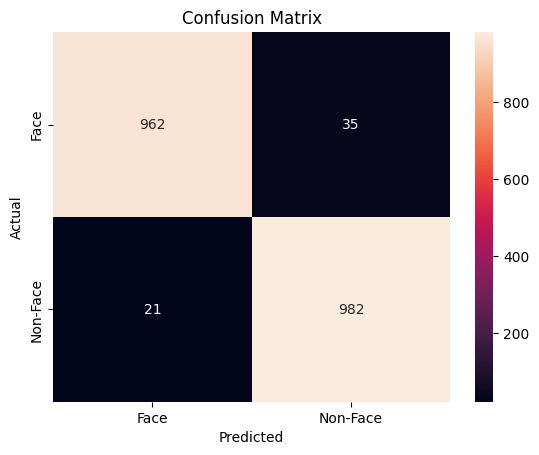

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
torch.save(model.state_dict(), "/kaggle/working/alexnet_scratch_model.pth")
print("Model saved!")

Model saved!
